In [47]:
import numpy as np
import matplotlib.pyplot as plt

**Constructing Hamiltonian matrix**

In [48]:
def hamiltonian_matrix(delta_x,potential_values):
  potential_values = np.asarray(potential_values,dtype=float)
  if delta_x <=0:
    raise ValueError("detla_x must be greater than 0")
  if potential_values.ndim != 1:
    raise ValueError("potential_values must be a one-dimensional array.")
  if potential_values.size == 0:
    raise ValueError("potential_values cannot be empty.")

  interior_points = len(potential_values)

  main_diag = 1/(delta_x**2) + potential_values
  off_diag = np.full(interior_points-1,-1/(2*(delta_x**2)))

  hamiltonian = (np.diag(main_diag) + np.diag(off_diag,k=1) + np.diag(off_diag,k=-1))

  return hamiltonian

**Constructing a energy variation with n function**

In [71]:
def energy_variation(xi,xf,interior_points,potential_func):
    delta_x = (xf - xi)/(interior_points + 1)
    interior_grid = (xi + delta_x*np.arange(1,interior_points+1))

    potential_values = potential_func(interior_grid)

    H = hamiltonian_matrix(delta_x,potential_values)
    eigenvalues,eigenvectors = np.linalg.eigh(H)

    n_i = 0
    n_f = len(eigenvalues)
    step = 1
    n = np.arange(n_i,n_f,step)

    plt.plot(n[:200],eigenvalues[:200])
    plt.xlabel("quantum number(n)")
    plt.ylabel("Energy value")
    plt.title("Variation of energy with quantum number")
    plt.grid(alpha=0.7)
    plt.show()

**Infinte Potential Well**

In [74]:
def infinte_potential_well(interior_grid):
  n = len(interior_grid)
  potential_values = np.zeros(n)
  return potential_values

def solve_and_plot(xi,xf,interior_points,state_index):
  delta_x = (xf - xi)/(interior_points + 1)
  interior_grid = (xi + delta_x*np.arange(1,interior_points+1))

  potential_values = infinte_potential_well(interior_grid)

  if state_index < 0 or state_index >= interior_points:
    raise ValueError("state_index must lie between 0 and interior_points - 1.")

  H = hamiltonian_matrix(delta_x,potential_values)

  eigenvalues,eigenvectors = np.linalg.eigh(H)

  phi_interior   = eigenvectors[:,state_index]
  energy_value   = eigenvalues[state_index]
  phi            = np.concatenate(([0.0],phi_interior,[0.0]))
  normalization  = np.sum(np.abs(phi)**2)*delta_x
  phi_normalized = phi/np.sqrt(normalization)
  full_grid      = np.concatenate(([xi],interior_grid,[xf]))
  quantum_number = state_index + 1

  plt.plot(full_grid,phi_normalized,label=f"State {quantum_number}")
  plt.axhline(0,linewidth=0.8,linestyle="--")
  plt.xlabel("Dimensionless position, x")
  plt.ylabel(r"Eigenvector $\phi(x)$")
  plt.title(f"Eigenvalue n = {quantum_number}, "f"Energy = {energy_value:.6f}")
  plt.grid(alpha=0.3)
  plt.legend()
  plt.show()

  return full_grid,phi,energy_value

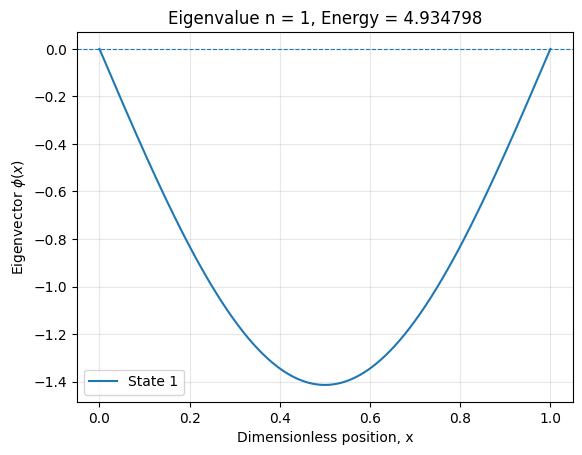

In [75]:
interior_points = 1000

x, phi, energy = solve_and_plot(
    xi=0,
    xf=1,
    interior_points=interior_points,
    state_index=0
)

**Comparing energy values with n**

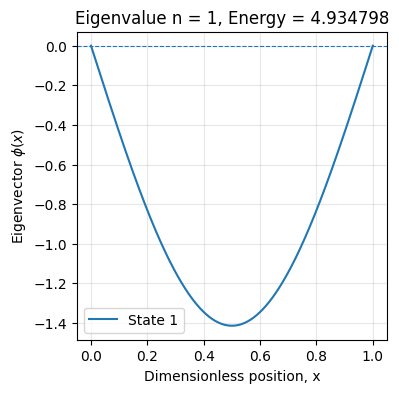

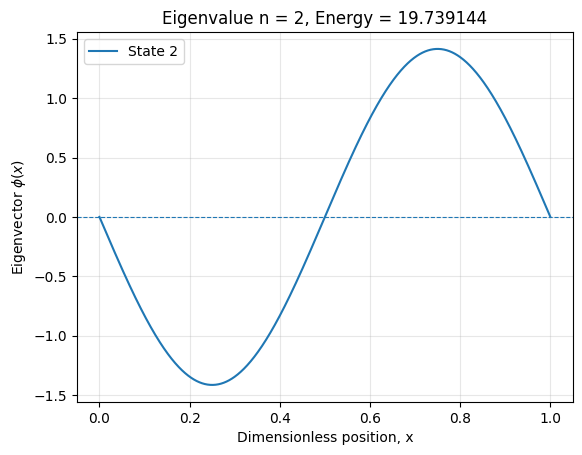

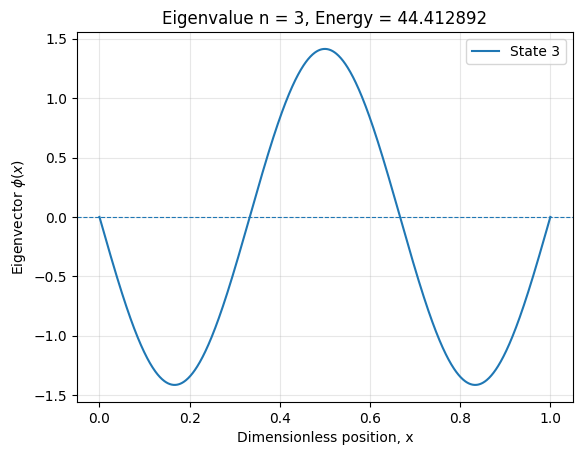

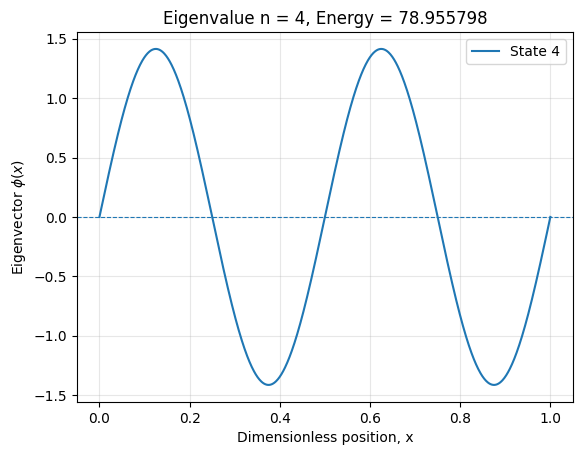

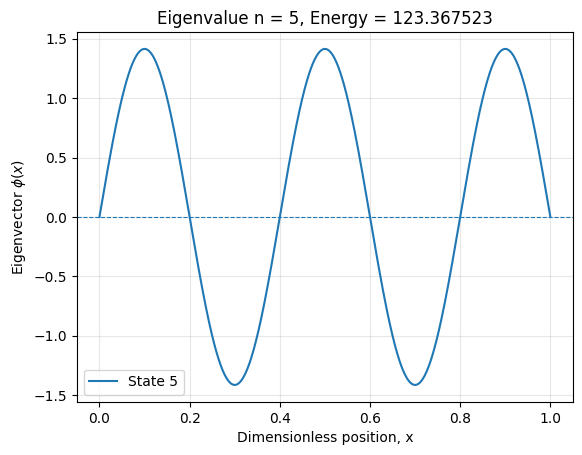

In [76]:
interior_points = 1000
states = [0,1,2,3,4]
plt.figure(figsize= (4,4))
for state_index in states:
    x, phi, energy = solve_and_plot(xi=0,xf=1,interior_points=interior_points,state_index=state_index)

**Energy vs n varitaion for infinite potential well**

**NOTE:- In infinite potential well we are supposed to get a parabolic but if you once plot the variation there will be falt ends in the curve this is due to the finite diffenrece method you are using.So to get a good parabolic curve we calculate eigenvalues for like 1000 n and then plot for initial 10 or 20 percent that's what we have done here check the energy_variation function in third cell we have sliced the the arrays you will see a line similar to:-**

plt.plot(n[:200],eigenvalues[:200])



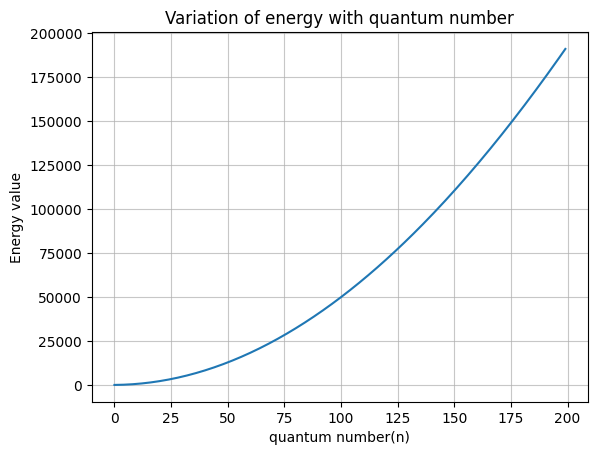

In [77]:
xi = 0
xf = 1
interior_points = 1000
energy_variation(xi,xf,interior_points,infinte_potential_well)

**Probability Distribution Curve and Area**

In [54]:
def probability_distributuion(xi,xf,interior_points,state_index,potential_values):
  delta_x = (xf - xi)/(interior_points + 1)
  interior_grid = (xi + delta_x*np.arange(1,interior_points+1))

  potential_values = np.asarray(potential_values,dtype=float)

  if state_index < 0 or state_index >= interior_points:
    raise ValueError("state_index must lie between 0 and interior_points - 1.")

  H = hamiltonian_matrix(delta_x,potential_values)

  eigenvalues,eigenvectors = np.linalg.eigh(H)

  phi_interior   = eigenvectors[:,state_index]
  energy_value   = eigenvalues[state_index]
  phi            = np.concatenate(([0.0],phi_interior,[0.0]))
  normalization  = np.sum(np.abs(phi)**2)*delta_x
  phi_normalized = phi/np.sqrt(normalization)
  full_grid      = np.concatenate(([xi],interior_grid,[xf]))
  quantum_number = state_index + 1
  probability_curve_raw = np.abs(phi)**2
  probability_curve = np.abs(phi_normalized)**2

  #Calculating area under the graph
  area_normalized = delta_x*np.sum(probability_curve[0]/2 + probability_curve[-1]/2 + np.sum(probability_curve[1:-1]))
  area_non_normalied = delta_x*np.sum(probability_curve_raw[0]/2 + probability_curve_raw[-1]/2 + np.sum(probability_curve_raw[1:-1]))


  fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,4))
  ax1.plot(full_grid,probability_curve_raw,label=f"State {quantum_number}")
  ax1.axhline(0,linewidth=0.8,linestyle="--")
  ax1.set_xlabel("Dimensionless position, x")
  ax1.set_ylabel(r"Eigenvector $\phi(x)$")
  ax1.set_title(f"Eigenvalue n = {quantum_number}, "f"Area_non_normalized = {area_non_normalied :.5F}")
  ax1.legend()


  ax2.plot(full_grid,probability_curve,label=f"State {quantum_number}")
  ax2.axhline(0,linewidth=0.8,linestyle="--")
  ax2.set_xlabel("Dimensionless position, x")
  ax2.set_ylabel(r"Eigenvector $\phi(x)$")
  ax2.set_title(f"Eigenvalue n = {quantum_number}, "f"Area_normalized = {area_normalized :.5F}")
  ax2.legend()
  
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()
  
  return full_grid,phi,energy_value

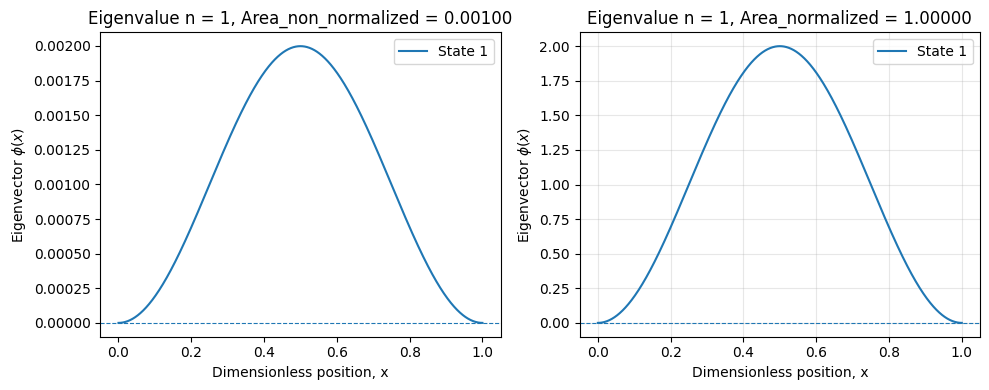

In [55]:
interior_points = 1000
potential_values = np.zeros(interior_points)

x, phi, energy = probability_distributuion(
    xi=0,
    xf=1,
    interior_points=interior_points,
    state_index=0,
    potential_values=potential_values
)

**Step Potential**

**Solution and plotting of Step potential**

In [56]:
def step_potential(x,x0,V0):
    potential_values = np.zeros(len(x))
    potential_values[x >= x0] = V0

    return potential_values

def solve_step_potential(xi,xf,interior_points,state_index,x0,v0):
  delta_x = (xf - xi)/(interior_points + 1)
  interior_grid = (xi + delta_x*np.arange(1,interior_points+1))

  potential_values = step_potential(interior_grid,x0,v0)

  if state_index < 0 or state_index >= interior_points:
    raise ValueError("state_index must lie between 0 and interior_points - 1.")
  if x0 > xf or x0 < xi:
     raise ValueError("x0 must lie between xi and xf")

  H = hamiltonian_matrix(delta_x,potential_values)

  eigenvalues,eigenvectors = np.linalg.eigh(H)

  phi_interior   = eigenvectors[:,state_index]
  energy_value   = eigenvalues[state_index]
  phi            = np.concatenate(([0.0],phi_interior,[0.0]))
  normalization  = np.sum(np.abs(phi)**2)*delta_x
  phi_normalized = phi/np.sqrt(normalization)
  full_grid      = np.concatenate(([xi],interior_grid,[xf]))
  check = np.sum(np.abs(phi_normalized)**2) * delta_x
  print("Normalization =", check)

  return phi,full_grid,phi_normalized,energy_value

def plot_step_potential(full_grid,phi_normalized,energy_value,state_index):
  quantum_number = state_index + 1
  plt.plot(full_grid,phi_normalized,label=f"State {quantum_number}")
  plt.axhline(0,linewidth=0.8,linestyle="--")
  plt.axvline(x0,linewidth=1.0)
  plt.xlabel("Dimensionless position, x")
  plt.ylabel(r"Wavefunction $\phi(x)$")
  plt.title(f"Eigenvalue n = {quantum_number}, "f"Energy = {energy_value:.6f}")
  plt.grid(alpha=0.3)
  plt.legend()
  plt.show()
    



Normalization = 1.0


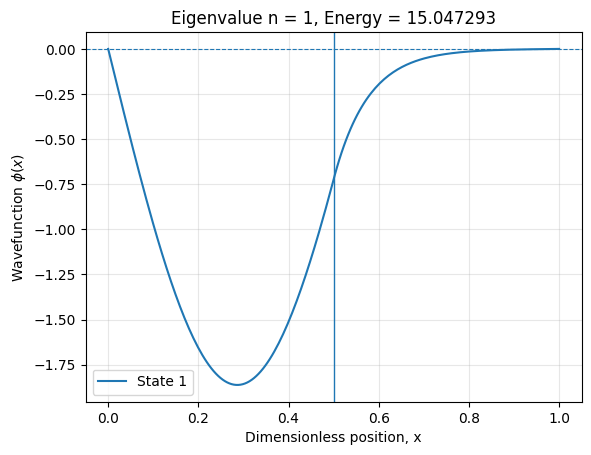

In [57]:
interior_points = 200
V0 = 100
x0 = 0.5
state_index = 0
phi,full_grid,phi_normalized,energy_value = solve_step_potential(0,1,interior_points,state_index,x0,V0)
plot_step_potential(full_grid,phi_normalized,energy_value,state_index)

**Comparing Change in wavefunction with changing potential values**

Normalization = 1.0


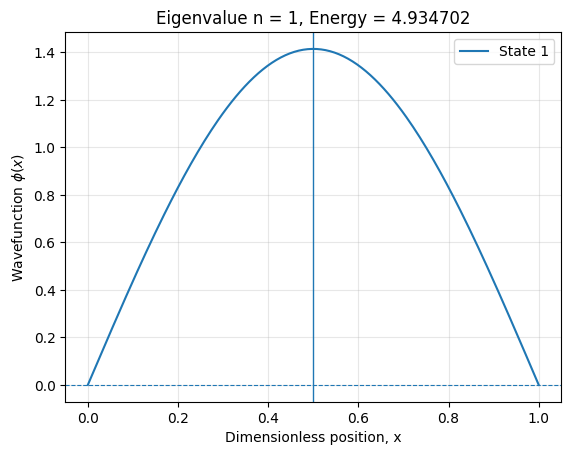

Normalization = 1.0000000000000002


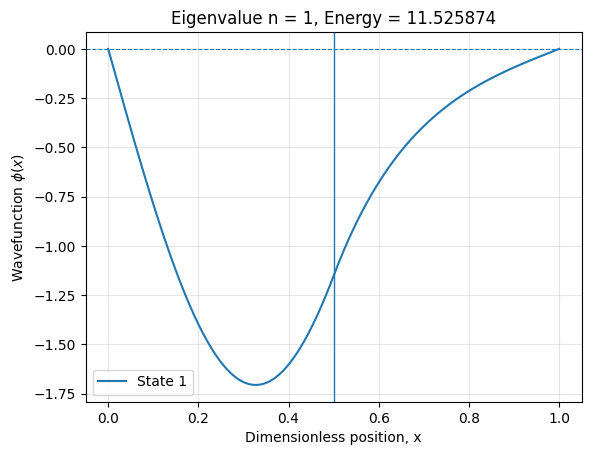

Normalization = 0.9999999999999999


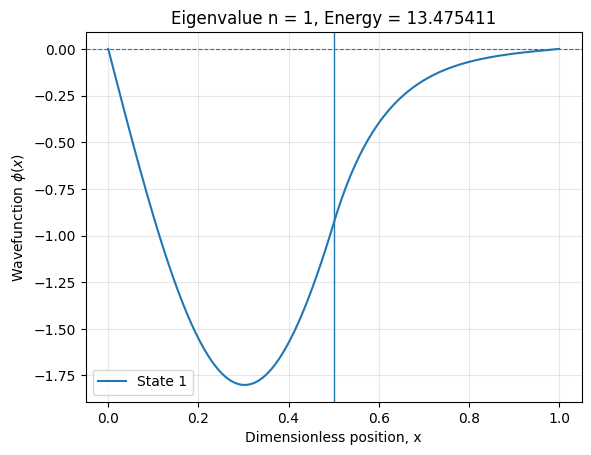

Normalization = 0.9999999999999997


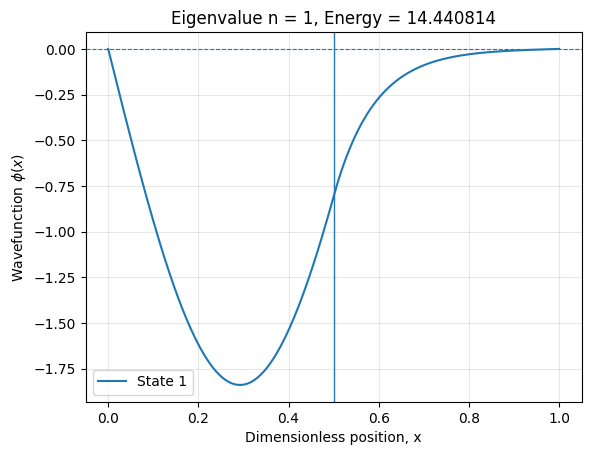

Normalization = 1.0


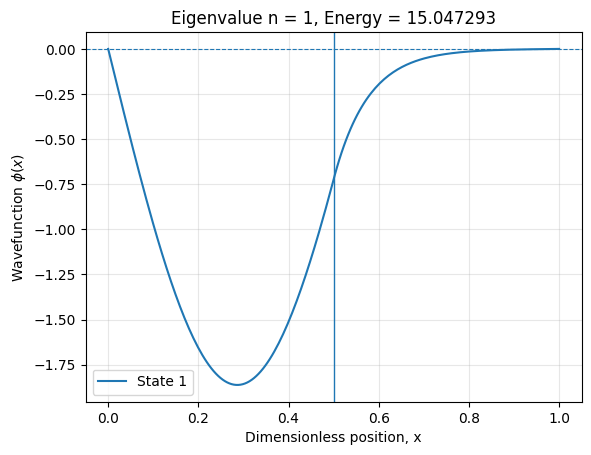

In [58]:
Vo_i   = 0
Vo_f   = 100
step   = 25
Vo_arr = np.arange(Vo_i,Vo_f+step,step,dtype=float)
interior_points = 200
x0 = 0.5
state_index = 0

for V0 in Vo_arr:
    phi,full_grid,phi_normalized,energy_value = solve_step_potential(0,1,interior_points,state_index,x0,V0)
    plot_step_potential(full_grid,phi_normalized,energy_value,state_index)


**Comparing different states for same potential**

Normalization = 1.0


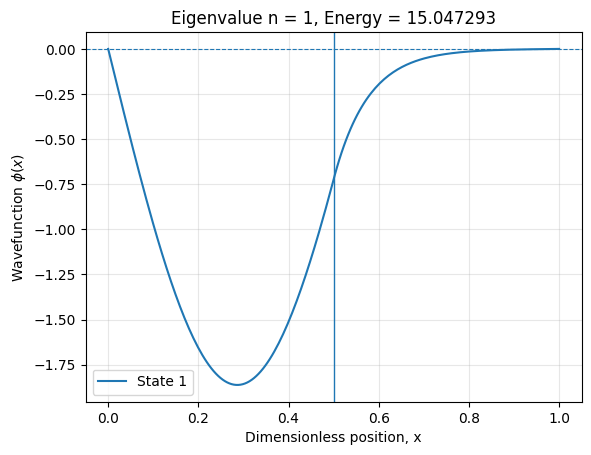

Normalization = 1.0


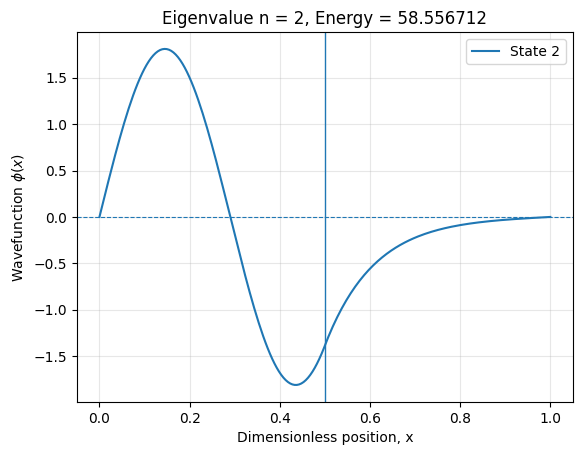

Normalization = 0.9999999999999999


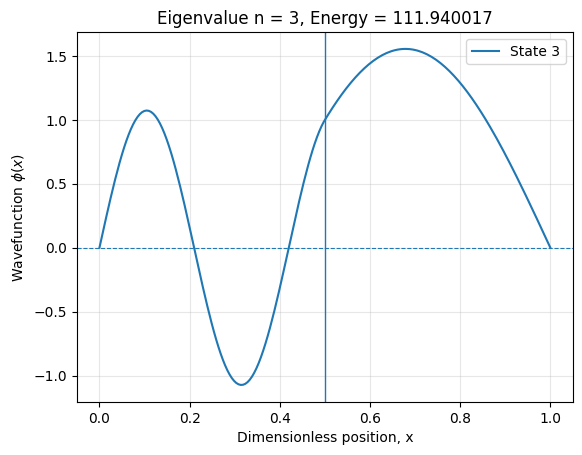

Normalization = 1.0000000000000002


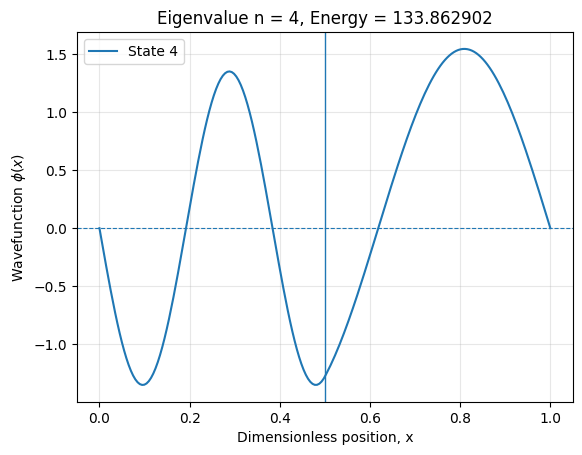

Normalization = 1.0


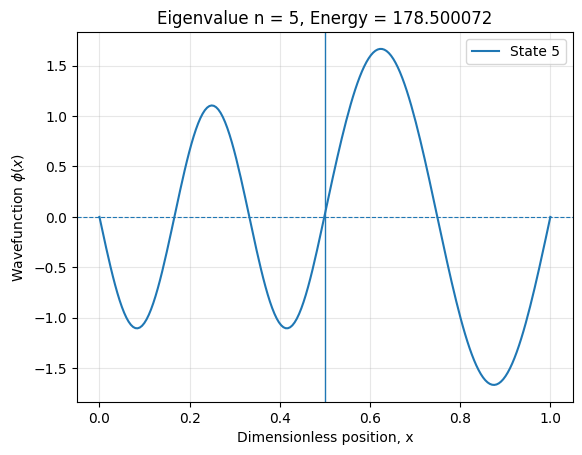

Normalization = 1.0


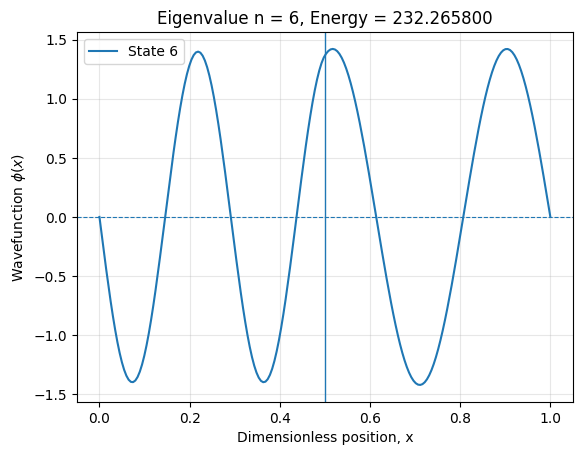

Normalization = 1.0


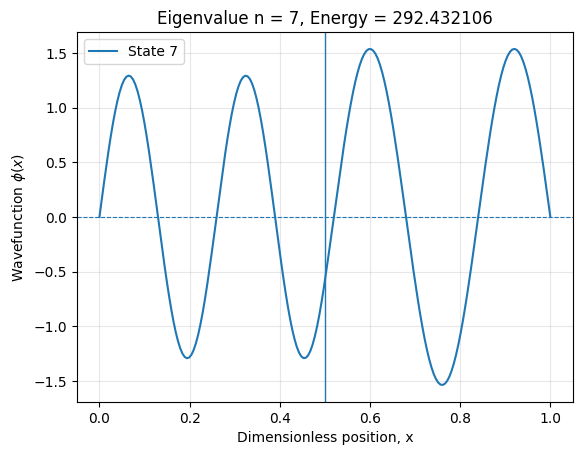

Normalization = 1.0


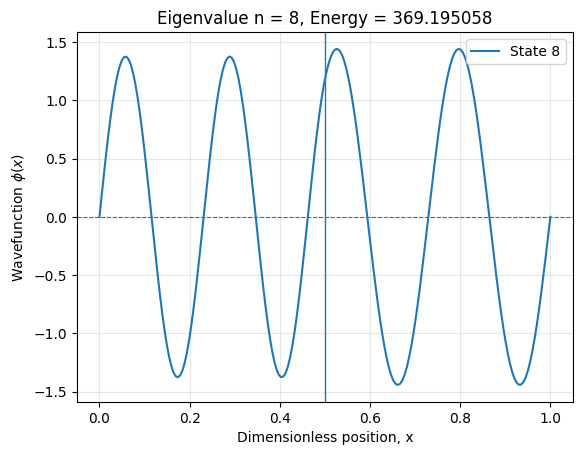

Normalization = 0.9999999999999997


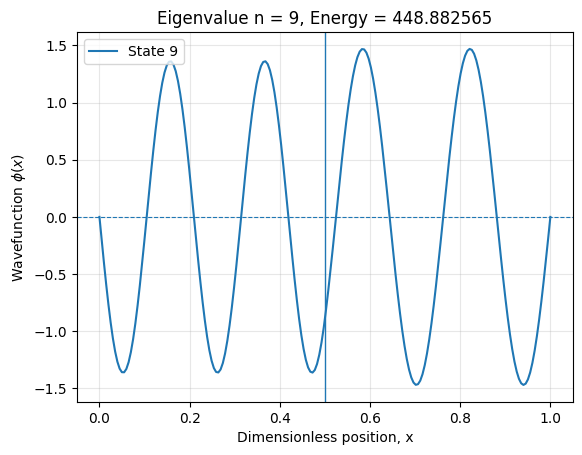

Normalization = 1.0


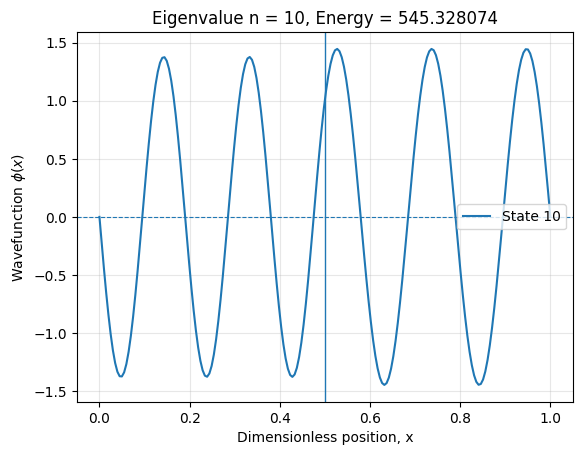

Normalization = 1.0000000000000002


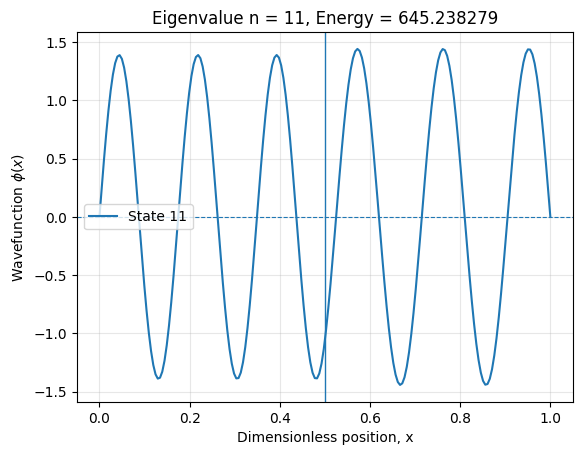

In [59]:
state_i = 0
state_f = 10
step    = 1
state_index_arr = np.arange(state_i,state_f+step,step)
interior_points = 200
V0 = 100
x0 = 0.5

for state_index in state_index_arr:
    phi,full_grid,phi_normalized,energy_value = solve_step_potential(0,1,interior_points,state_index,x0,V0)
    plot_step_potential(full_grid,phi_normalized,energy_value,state_index)

**Calculating Transmission and Reflection coefficient**

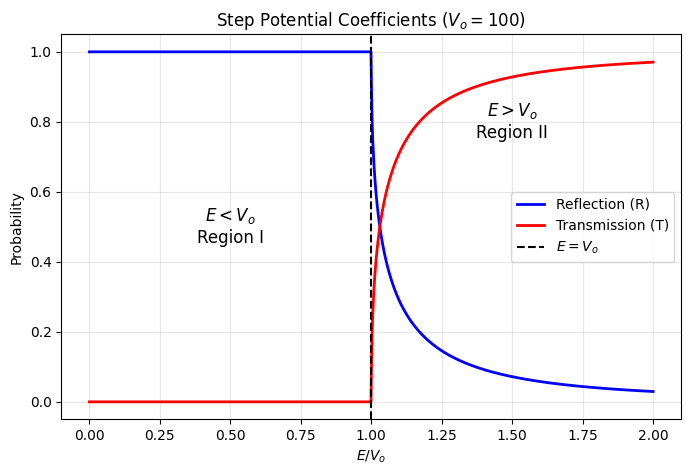

In [60]:
Eo_i = 0
Eo_f = 200
points = 1000
E = np.linspace(Eo_i,Eo_f,points)
Vo  = 100
temp = np.sqrt((E - Vo).astype(complex)) 

reflection_coefficient_num = np.sqrt(E) - temp
reflection_coefficient_den = np.sqrt(E) + temp
reflection_coefficient     = np.abs(reflection_coefficient_num/reflection_coefficient_den)**2

transmission_coefficient     = 1 - reflection_coefficient

reflection_coefficient[0] = 1.0
transmission_coefficient[0] = 0.0

x_val = E/Vo

plt.figure(figsize=(8, 5))
plt.plot(x_val, reflection_coefficient, color="blue", label="Reflection (R)", lw=2)
plt.plot(x_val, transmission_coefficient, color="red", label="Transmission (T)", lw=2)
plt.axvline(x=1.0, color='black', linestyle='--', label='$E = V_o$')
plt.title("Step Potential Coefficients ($V_o = 100$)")
plt.xlabel("$E / V_o$")
plt.ylabel("Probability")
plt.text(0.5, 0.5, '$E < V_o$\nRegion I', fontsize=12, ha='center', va='center')
plt.text(1.5, 0.8, '$E > V_o$\nRegion II', fontsize=12, ha='center', va='center')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


**Probability Densities**

In [61]:
def plot_probability_step_potential(full_grid,phi,phi_normalized,state_index):
    xi      = full_grid[0]
    xf      = full_grid[-1]
    delta_x = (xf - xi)/(interior_points + 1)

    probability_curve = np.abs(phi_normalized)**2
    probability_curve_raw = np.abs(phi)**2

    quantum_number = state_index + 1

    area_normalized = delta_x*np.sum(probability_curve[0]/2 + probability_curve[-1]/2 + np.sum(probability_curve[1:-1]))
    area_non_normalied = delta_x*np.sum(probability_curve_raw[0]/2 + probability_curve_raw[-1]/2 + np.sum(probability_curve_raw[1:-1]))

    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,4))
    ax1.plot(full_grid,probability_curve_raw,label=f"State {quantum_number}")
    ax1.axhline(0,linewidth=0.8,linestyle="--")
    ax1.set_xlabel("Dimensionless position, x")
    ax1.set_ylabel(r"Eigenvector $\phi(x)$")
    ax1.set_title(f"Eigenvalue n = {quantum_number}, "f"Area_non_normalized = {area_non_normalied :.5F}")
    ax1.legend()


    ax2.plot(full_grid,probability_curve,label=f"State {quantum_number}")
    ax2.axhline(0,linewidth=0.8,linestyle="--")
    ax2.set_xlabel("Dimensionless position, x")
    ax2.set_ylabel(r"Eigenvector $\phi(x)$")
    ax2.set_title(f"Eigenvalue n = {quantum_number}, "f"Area_normalized = {area_normalized :.5F}")
    ax2.legend()
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Normalization = 1.0


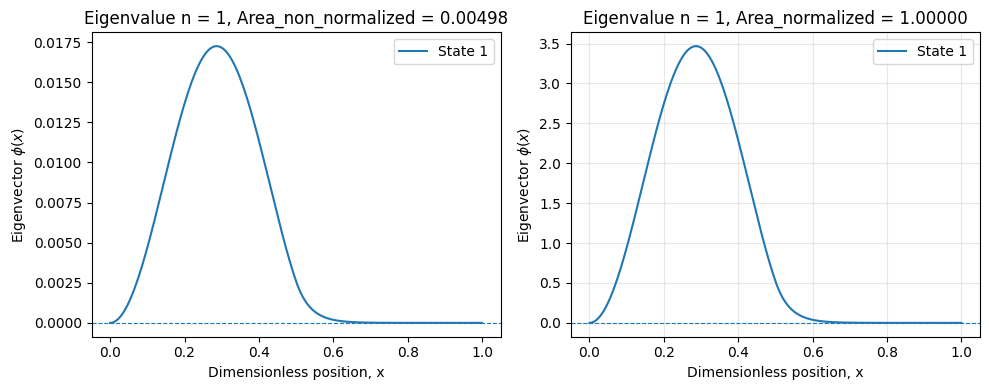

In [62]:
interior_points = 200
V0 = 100
x0 = 0.5
state_index = 0
phi,full_grid,phi_normalized,energy_value = solve_step_potential(0,1,interior_points,state_index,x0,V0)
plot_probability_step_potential(full_grid,phi,phi_normalized,state_index)

**Harmonic Oscillator**

In [63]:
def harmonic_potential(x):
    potential_values = np.array(np.multiply(x,x)/2)
    return potential_values

def solve_harmonic_potential(xi,xf,interior_points,state_index):
  delta_x = (xf - xi)/(interior_points + 1)
  interior_grid = (xi + delta_x*np.arange(1,interior_points+1))

  potential_values = harmonic_potential(interior_grid)

  if state_index < 0 or state_index >= interior_points:
    raise ValueError("state_index must lie between 0 and interior_points - 1.")

  H = hamiltonian_matrix(delta_x,potential_values)

  eigenvalues,eigenvectors = np.linalg.eigh(H)

  phi_interior   = eigenvectors[:,state_index]
  energy_value   = eigenvalues[state_index]
  phi            = np.concatenate(([0.0],phi_interior,[0.0]))
  normalization  = np.sum(np.abs(phi)**2)*delta_x
  phi_normalized = phi/np.sqrt(normalization)
  full_grid      = np.concatenate(([xi],interior_grid,[xf]))

  return phi,full_grid,phi_normalized,energy_value

def plot_harmonic_potential(full_grid,phi,phi_normalized,energy_value,state_index):
  quantum_number = state_index + 1
  potential_values = harmonic_potential(full_grid)
  fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,4))
  ax1.plot(full_grid,phi,label=f"State {quantum_number}")
  ax1.axhline(0,linewidth=0.8,linestyle="--")
  ax1.set_xlabel("Dimensionless position, x")
  ax1.set_ylabel(r"Eigenvector $\phi(x)$")
  ax1.set_title(f"Eigenvalue n = {quantum_number}, "f"Energy = {energy_value:.6f}")
  ax1.text(-6.0,0.15, 'Non-Normalized', fontsize=12, ha='center', va='center')
  ax1.legend()

  ax2.plot(full_grid,phi_normalized,label=f"State {quantum_number}")
  ax2.axhline(0,linewidth=0.8,linestyle="--")
  ax2.set_xlabel("Dimensionless position, x")
  ax2.set_ylabel(r"Eigenvector $\phi(x)$")
  ax2.set_title(f"Eigenvalue n = {quantum_number}, "f"Energy = {energy_value:.6f}")
  ax2.text(-6.0,0.15, 'Normalized', fontsize=12, ha='center', va='center')
  ax2.legend()
  
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()
    



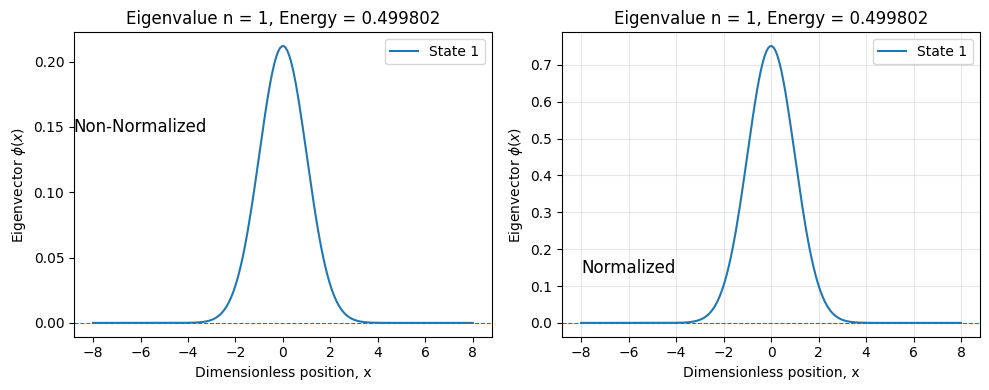

In [64]:
xi = -8
xf = 8
interior_points = 200
state_index = 0
phi,full_grid,phi_normalized,energy_value = solve_harmonic_potential(xi,xf,interior_points,state_index)
plot_harmonic_potential(full_grid,phi,phi_normalized,energy_value,state_index)

**Probability densities**

In [65]:
def harmonic_probability_curve(full_grid,phi,phi_normalized,state_index):
    xi      = full_grid[0]
    xf      = full_grid[-1]
    delta_x = (xf - xi)/(interior_points + 1)

    probability_curve = np.abs(phi_normalized)**2
    probability_curve_raw = np.abs(phi)**2

    quantum_number = state_index + 1

    area_normalized = delta_x*np.sum(probability_curve[0]/2 + probability_curve[-1]/2 + np.sum(probability_curve[1:-1]))
    area_non_normalied = delta_x*np.sum(probability_curve_raw[0]/2 + probability_curve_raw[-1]/2 + np.sum(probability_curve_raw[1:-1]))

    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,4))
    ax1.plot(full_grid,probability_curve_raw,label=f"State {quantum_number}")
    ax1.axhline(0,linewidth=0.8,linestyle="--")
    ax1.set_xlabel("Dimensionless position, x")
    ax1.set_ylabel(r"Eigenvector $\phi(x)$")
    ax1.set_title(f"Eigenvalue n = {quantum_number}, "f"Area_non_normalized = {area_non_normalied :.5F}")
    ax1.legend()


    ax2.plot(full_grid,probability_curve,label=f"State {quantum_number}")
    ax2.axhline(0,linewidth=0.8,linestyle="--")
    ax2.set_xlabel("Dimensionless position, x")
    ax2.set_ylabel(r"Eigenvector $\phi(x)$")
    ax2.set_title(f"Eigenvalue n = {quantum_number}, "f"Area_normalized = {area_normalized :.5F}")
    ax2.legend()
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

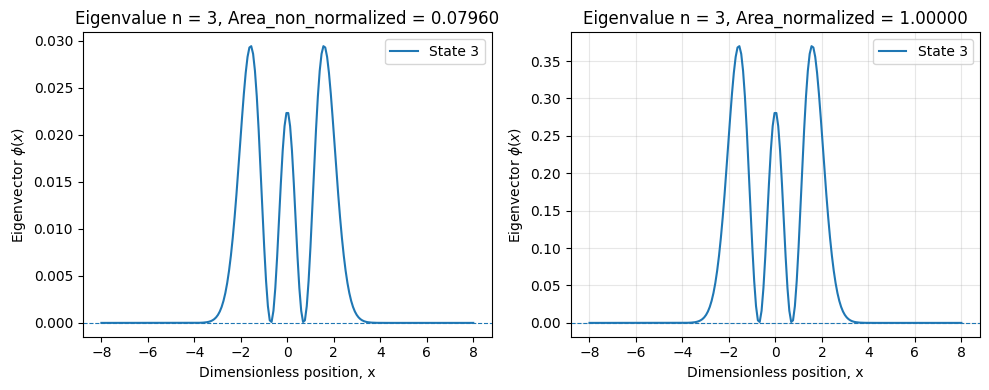

In [66]:
xi = -8
xf = 8
interior_points = 200
state_index = 2
phi,full_grid,phi_normalized,energy_value = solve_harmonic_potential(xi,xf,interior_points,state_index)
harmonic_probability_curve(full_grid,phi,phi_normalized,state_index)

**Plotting multiple wavefunction for a harmonic oscillator**

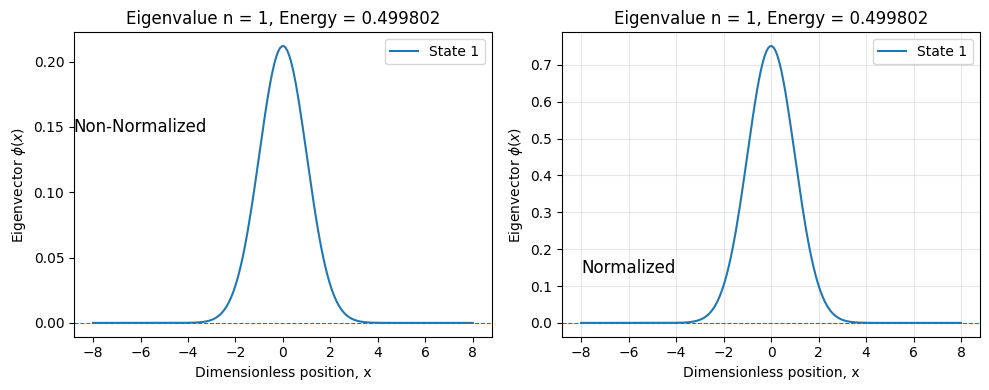

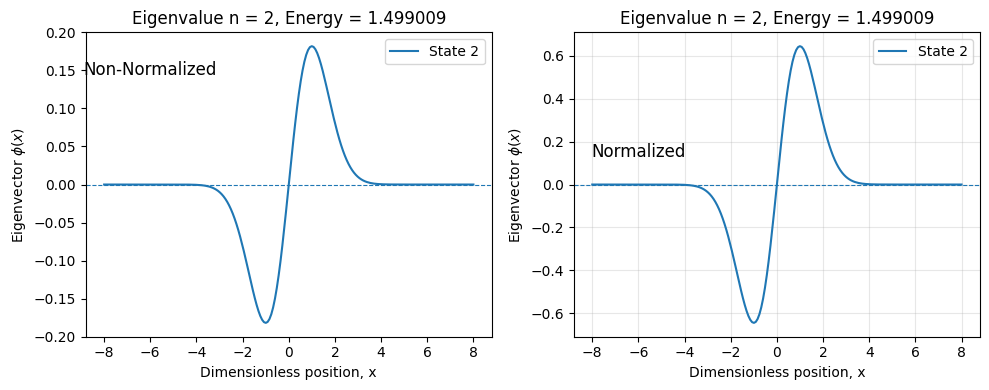

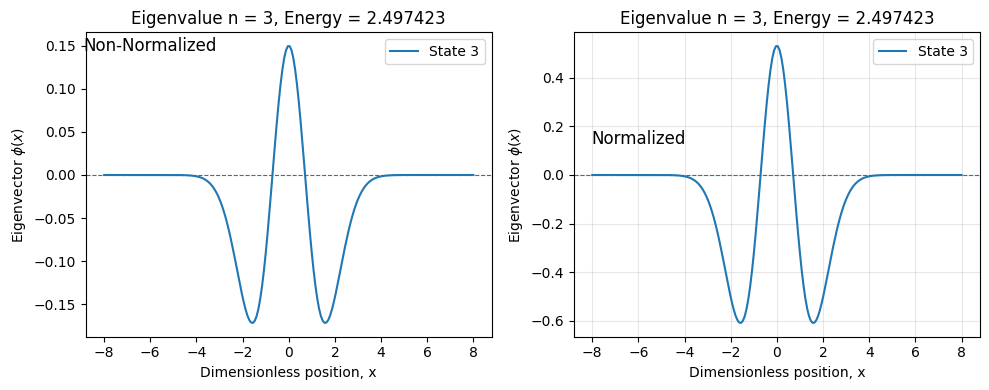

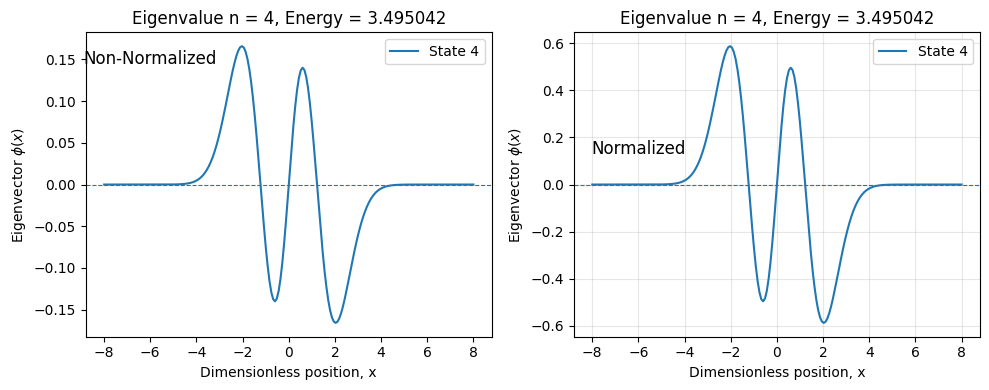

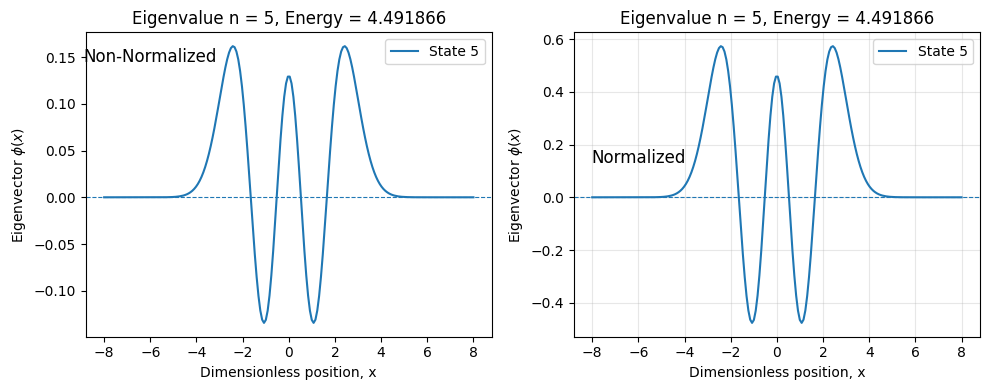

In [67]:
xi = -8
xf = 8
interior_points = 200
state_index_arr = [0,1,2,3,4]

for state_index in state_index_arr:
    phi,full_grid,phi_normalized,energy_value = solve_harmonic_potential(xi,xf,interior_points,state_index)
    plot_harmonic_potential(full_grid,phi,phi_normalized,energy_value,state_index)

**Energy variation with quantum number**

**NOTE:-We are supposed to get a linear variation but we won't get a perfectly linear variation as in reality harmonic oscilator extend from -infinity to infinity but here we are taking some finite value so there will be some component of particle in a box and as it have a parabloic variation it will diverges to parabolic later but initally we will get staright line.And if we extend our xi and xf to a very large value still we will still not get staright line as hamiltonian have two comonents kinetic and potential but with large x potential component dominates and as potential is parabolic it will give a parabola as energy is mostly potential this problem is called diagonal dominance.Here to get a almost straight we have performed slicing in energy_variation function**

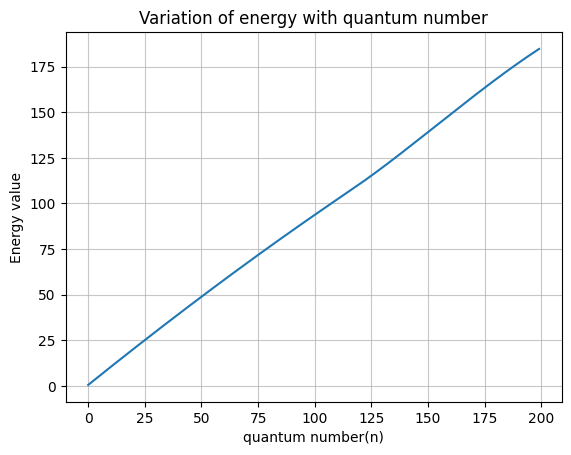

In [78]:
xi = -15
xf = 15
interior_points = 300
energy_variation(xi,xf,interior_points,harmonic_potential)
